<a href="https://colab.research.google.com/github/manavaditya21/Soft-Sensor-Design-for-Sulfur-Recovery-Unit/blob/main/CH512_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Libraries


In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


### Import Data

In [78]:
data= pd.read_csv("/content/drive/MyDrive/Machine Learning/CH-512/Project/Table - IN_Table.csv.csv")
data

,IN1,IN2,IN3,IN4,IN5,Out1,Out2
0,0.077744,0.795565,-0.665503,0.879321,0.134419,-0.122686,0.123661
1,0.080313,0.824595,-0.655447,0.875636,0.134941,-0.122686,0.123661
2,0.087355,0.776258,-0.650550,0.884105,0.132452,-0.026857,0.123661
3,0.091774,0.739149,-0.644934,0.892043,0.131287,-0.026857,0.251010
4,0.091166,0.761332,-0.648654,0.892752,0.136788,-0.026857,0.251010
...,...,...,...,...,...,...,...
14396,-2.371841,-1.399878,-2.594168,-0.861832,-1.607387,-2.039274,-1.531870
14397,-2.378745,-1.407683,-2.601522,-0.871577,-1.604817,-2.039274,-1.531870
14398,-2.385070,-1.388787,-2.606594,-0.880330,-1.579605,-1.943445,-1.659219
14399,-2.386119,-1.372492,-2.615738,-0.886744,-1.556761,-1.943445,-1.659219


## Visualizing the Data


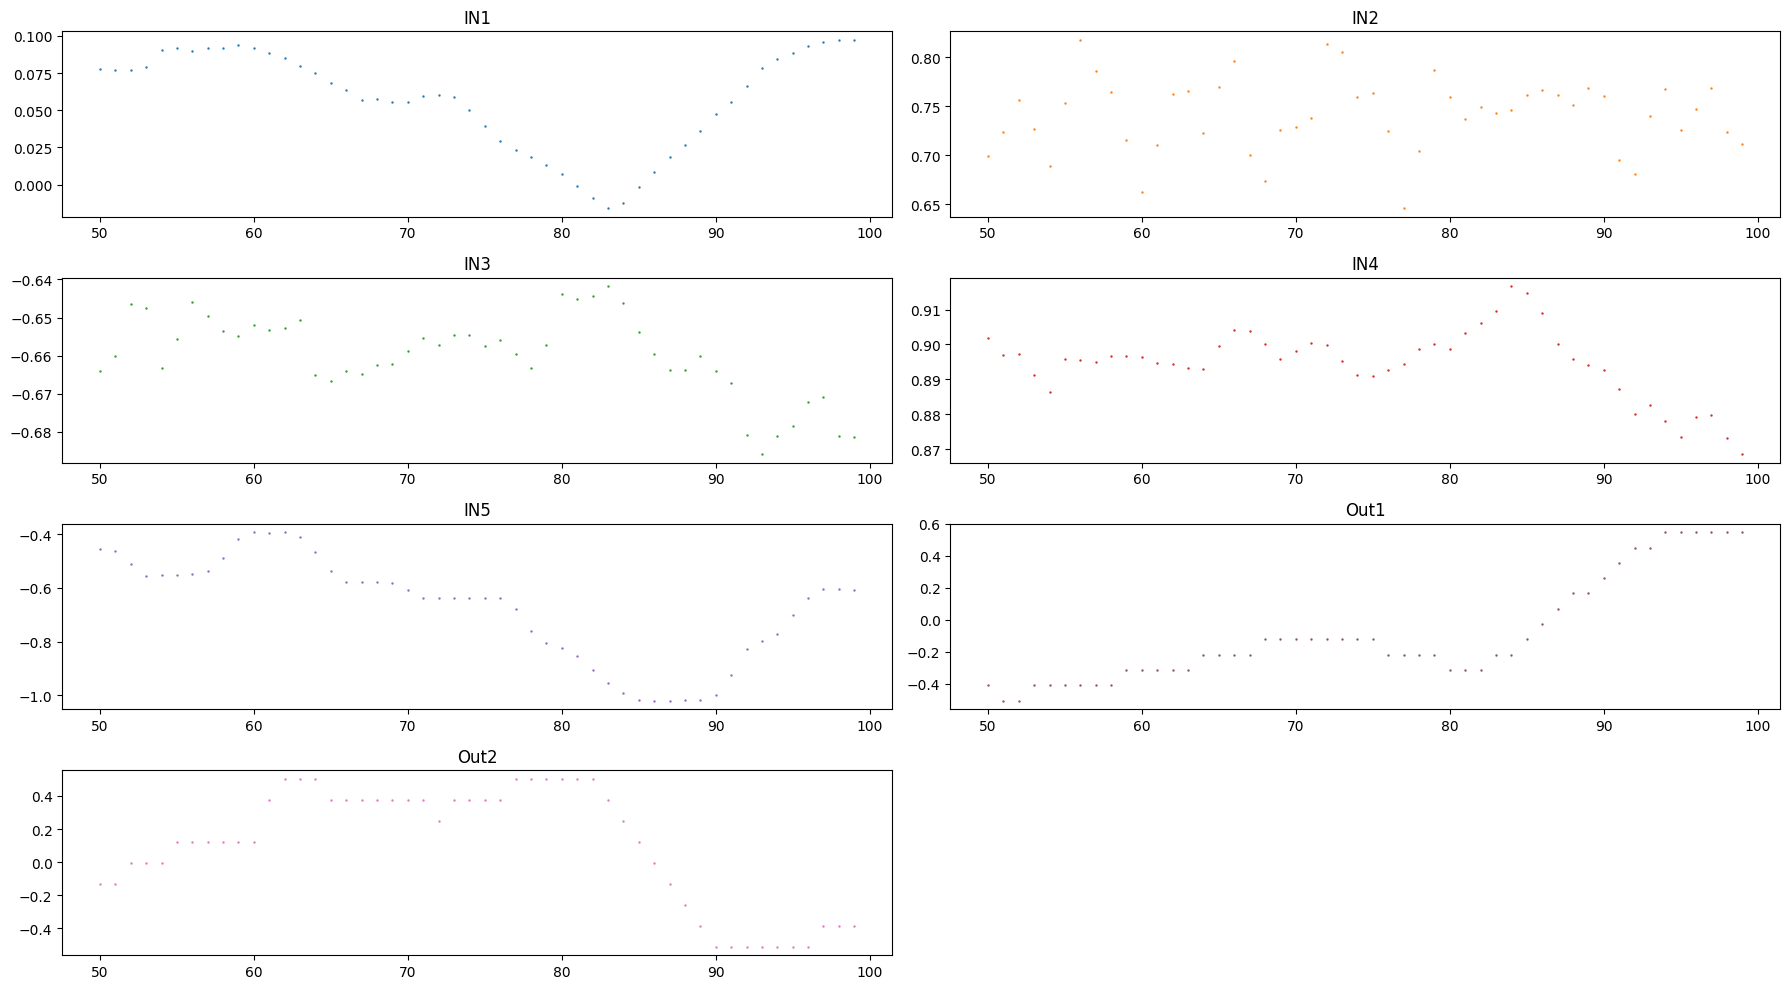

In [79]:
plt.figure(figsize=(18, 10))
n,m=50,100
for i, col in enumerate(data.columns, start=1):
    plt.subplot(4, 2, i)
    plt.scatter(data.index[n:m], data[col].iloc[n:m], marker='.', color='C{}'.format(i-1), s=2)
    plt.title(col)

plt.tight_layout()
plt.show()

In [80]:
data.corr()

,IN1,IN2,IN3,IN4,IN5,Out1,Out2
IN1,1.000000,0.500407,0.924350,0.438273,0.455514,0.624829,0.381853
IN2,0.500407,1.000000,0.321950,0.895081,0.081605,0.388346,0.201564
IN3,0.924350,0.321950,1.000000,0.197927,0.365890,0.572199,0.415136
IN4,0.438273,0.895081,0.197927,1.000000,0.013679,0.301107,0.203665
IN5,0.455514,0.081605,0.365890,0.013679,1.000000,0.428711,0.101761
Out1,0.624829,0.388346,0.572199,0.301107,0.428711,1.000000,-0.151741
Out2,0.381853,0.201564,0.415136,0.203665,0.101761,-0.151741,1.000000


#Linear Regression

In [81]:
x  = data.loc[n:m,['IN1','IN2','IN5']]
y1 = data.loc[n:m,'Out1']

### Splitting the dataset into the Training set and Test set

In [82]:
from sklearn.model_selection import train_test_split
x_train, x_test, y1_train, y1_test, y2_train, y2_test = train_test_split(x, y1, y2, test_size=0.2, random_state=42)
x_test

,IN1,IN2,IN5
93,0.078462,0.739970,-0.797288
90,0.047780,0.760373,-1.000114
96,0.093265,0.747091,-0.636496
62,0.084869,0.762975,-0.393643
74,0.050237,0.759141,-0.636577
81,-0.001103,0.736958,-0.854578
67,0.057225,0.700123,-0.580209
82,-0.008698,0.749556,-0.905365
53,0.079346,0.727236,-0.556883
80,0.006906,0.759415,-0.822219


### Training the Multiple Linear Regression model on the Training set

In [83]:
from sklearn.linear_model import LinearRegression
regressor_y1 = LinearRegression()
regressor_y1.fit(x_train, y1_train)

regressor_y2 = LinearRegression()
regressor_y2.fit(x_train, y1_train)

LinearRegression()

## Predicting the Test set results

In [84]:
y1_test_values = y1_test.values
y1_pred = regressor_y1.predict(x_test)
print(np.concatenate((y1_pred.reshape(len(y1_pred),1), y1_test_values.reshape(len(y1_test_values),1)),1))

[[ 0.39  0.45]
 [ 0.46  0.26]
 [ 0.19  0.55]
 [-0.43 -0.31]
 [-0.27 -0.12]
 [-0.31 -0.31]
 [-0.21 -0.22]
 [-0.3  -0.31]
 [-0.08 -0.41]
 [-0.33 -0.31]
 [-0.45 -0.31]]


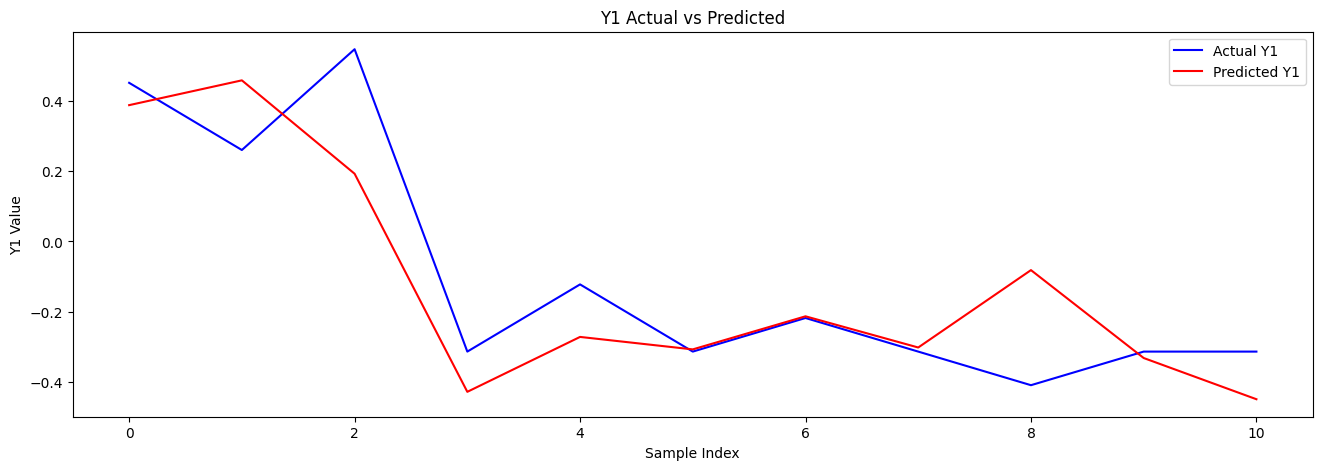

In [85]:
# Create scatter plot for Y1 predictions
plt.figure(figsize=(16, 5))
plt. plot(range(len(y1_test)), y1_test, color='blue', label='Actual Y1')
plt.plot(range(len(y1_test)), y1_pred, color='red', label='Predicted Y1')
plt.xlabel('Sample Index')
plt.ylabel('Y1 Value')
plt.title('Y1 Actual vs Predicted')
plt.legend()
plt.show()


## Evaluating the Model Performance

In [94]:
from sklearn.metrics import r2_score
print(r2_score(y1_test, y1_pred))

n_samples = len(y1_test)
n_parameters = x_train.shape[1] + 1
n_samples * np.log(np.mean((y1_test - y1_pred) ** 2)) + 2 * n_parameters

0.722296460443147


-30.50589882816812

In [95]:
print(np.mean((y1_test - y1_pred) ** 2))


0.030181194202050014


#Polynomial


In [88]:
x  = data.loc[n:m,['IN1','IN4','IN5']]
y2 = data.loc[n:m,'Out2']

In [89]:
from sklearn.model_selection import train_test_split
x_train, x_test, y1_train, y1_test, y2_train, y2_test = train_test_split(x, y1, y2, test_size=0.2, random_state=42)
x_test

,IN1,IN4,IN5
93,0.078462,0.882794,-0.797288
90,0.047780,0.892646,-1.000114
96,0.093265,0.879109,-0.636496
62,0.084869,0.894311,-0.393643
74,0.050237,0.891370,-0.636577
81,-0.001103,0.903170,-0.854578
67,0.057225,0.903808,-0.580209
82,-0.008698,0.906183,-0.905365
53,0.079346,0.891264,-0.556883
80,0.006906,0.898741,-0.822219


In [90]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 2)
x_poly = poly_reg.fit_transform(x_train)
regressor = LinearRegression()
regressor.fit(x_poly, y2_train)

LinearRegression()

In [91]:
y2_test_values = y2_test.values
y2_pred = regressor.predict(poly_reg.transform(x_test))
np.set_printoptions(precision=2)
print(np.concatenate((y1_pred.reshape(len(y2_pred),1), y1_test_values.reshape(len(y2_test),1)),1))

[[ 0.39  0.45]
 [ 0.46  0.26]
 [ 0.19  0.55]
 [-0.43 -0.31]
 [-0.27 -0.12]
 [-0.31 -0.31]
 [-0.21 -0.22]
 [-0.3  -0.31]
 [-0.08 -0.41]
 [-0.33 -0.31]
 [-0.45 -0.31]]


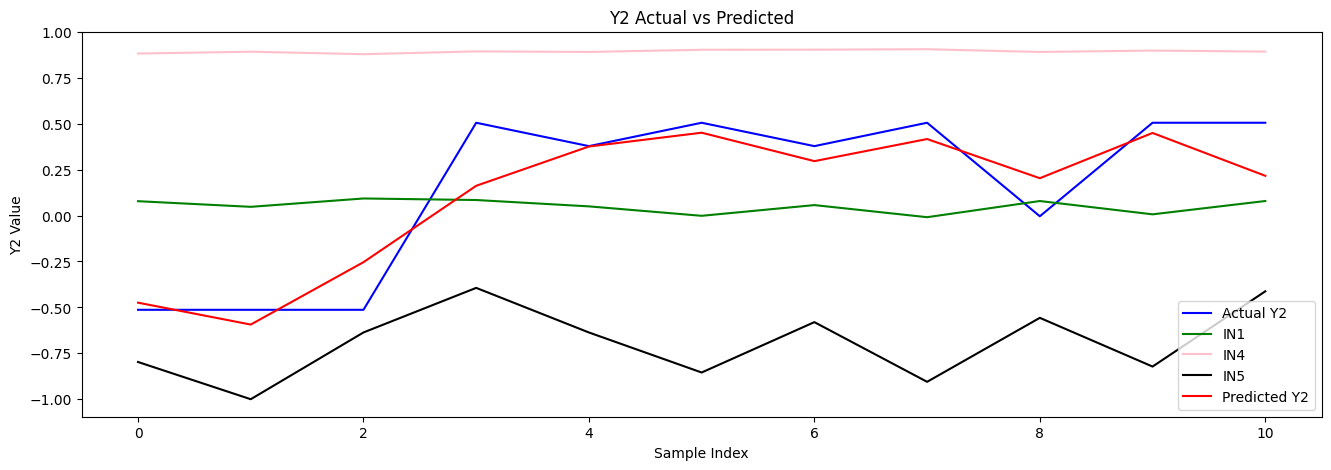

In [92]:
# Create scatter plot for Y2 predictions
plt.figure(figsize=(16, 5))
plt.plot(range(len(y2_test)), y2_test, color='blue', label='Actual Y2')

plt.plot(range(len(x_test.loc[:,['IN1']])), x_test.loc[:,['IN1']], color='green', label='IN1')
plt.plot(range(len(x_test.loc[:,['IN4']])), x_test.loc[:,['IN4']], color='pink', label='IN4')
plt.plot(range(len(x_test.loc[:,['IN5']])), x_test.loc[:,['IN5']], color='black', label='IN5')

plt.plot(range(len(y2_test)), y2_pred, color='red', label='Predicted Y2')
plt.xlabel('Sample Index')
plt.ylabel('Y2 Value')
plt.title('Y2 Actual vs Predicted')
plt.legend()
plt.show()

In [93]:
from sklearn.metrics import r2_score
print('R2  =' ,r2_score(y2_test, y2_pred))
n_samples = len(y2_test)
n_parameters = x_train.shape[1] + 1
print('AIC =',n_samples * np.log(np.mean((y2_test - y2_pred) ** 2)) + 2 * n_parameters)

R2  = 0.8363370596520805
AIC = -30.23650879756486


#